In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(42)

# Device
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device( 'cpu')

# PINN model
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.net = nn.Sequential()
        for i in range(len(layers) - 1):
            self.net.add_module(f"layer{i}", nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                self.net.add_module(f"tanh{i}", nn.Tanh())

    def forward(self, x):
        return self.net(x)

In [2]:
q_0=0.015
l=10
EI=20.83

# Right-hand side of Bernoulli equation
def f(x):
    return q_0*torch.sin(np.pi*x/l)

# PDE residual
def pde_loss(model, X):
    X.requires_grad_(True)
    u = model(X)
    u_x = torch.autograd.grad(u, X, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, X, torch.ones_like(u_x), create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, X, torch.ones_like(u_x), create_graph=True)[0]
    u_xxxx = torch.autograd.grad(u_xxx, X, torch.ones_like(u_x), create_graph=True)[0]
    source = f(X)
    return torch.mean((source-u_xxxx*EI)**2) + torch.mean(u_x[1]**2) + torch.mean(torch.relu(u_xx[1]))

# Boundary loss
def boundary_loss(model, Xb):
    Xb.requires_grad_(True)
    u=model(Xb)
    u_x = torch.autograd.grad(u, Xb, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, Xb, torch.ones_like(u_x), create_graph=True)[0]
    loss = torch.mean(u**2) + torch.mean(u_xx**2) + torch.mean(torch.relu(-u_x[0])) + torch.mean(torch.relu(u_x[1]))
    return loss

# Generate collocation and boundary points
def generate_points(n_interior):
    # Interior points and boundary points
    # x_in = torch.rand(n_interior,1).to(device)
    x_in = torch.tensor([[2.5], [5], [7.5]], dtype=torch.float32).to(device)
    x_b = torch.tensor([[0],[10]], dtype=torch.float32).to(device)
    return x_in, x_b

# Train the model



###########(__init__)############
# layers = [1, 32, 32,  1]
# model = PINN(layers).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# X_in, X_b = generate_points(3)
# loss_vec = []

###########(__run__)#############
# optimizer.param_groups[0]['lr'] = 1e-5


for epoch in range(40000):

    optimizer.zero_grad()
    loss_in = 1 * pde_loss(model, X_in)
    loss_b = 1 * boundary_loss(model, X_b)
    loss = loss_in + loss_b
    loss.backward()
    optimizer.step()
    loss_vec.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch:05d}, Loss (pde): {loss_in.item():.2e}, Loss (bc): {loss_b.item():.2e}, Total Loss: {loss.item():.2e}") 

Epoch 00000, Loss (pde): 1.16e-01, Loss (bc): 4.31e-01, Total Loss: 5.46e-01
Epoch 00100, Loss (pde): 1.19e-02, Loss (bc): 4.75e-02, Total Loss: 5.94e-02
Epoch 00200, Loss (pde): 3.06e-03, Loss (bc): 1.07e-02, Total Loss: 1.37e-02
Epoch 00300, Loss (pde): 1.85e-03, Loss (bc): 2.66e-03, Total Loss: 4.51e-03
Epoch 00400, Loss (pde): 1.50e-03, Loss (bc): 9.05e-04, Total Loss: 2.40e-03
Epoch 00500, Loss (pde): 1.17e-03, Loss (bc): 3.69e-04, Total Loss: 1.54e-03
Epoch 00600, Loss (pde): 8.84e-04, Loss (bc): 1.45e-04, Total Loss: 1.03e-03
Epoch 00700, Loss (pde): 7.00e-04, Loss (bc): 5.32e-05, Total Loss: 7.53e-04
Epoch 00800, Loss (pde): 5.84e-04, Loss (bc): 5.43e-05, Total Loss: 6.38e-04
Epoch 00900, Loss (pde): 5.06e-04, Loss (bc): 8.15e-05, Total Loss: 5.87e-04
Epoch 01000, Loss (pde): 3.89e-04, Loss (bc): 4.34e-05, Total Loss: 4.32e-04
Epoch 01100, Loss (pde): 3.29e-04, Loss (bc): 2.23e-05, Total Loss: 3.52e-04
Epoch 01200, Loss (pde): 2.83e-04, Loss (bc): 2.09e-05, Total Loss: 3.04e-04

KeyboardInterrupt: 

C:\Users\iagr9\AppData\Local\Temp\ipykernel_48404\2142286619.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  u_exact = q_0*l**4/(np.pi**4*EI)*np.sin(np.pi*x/l)


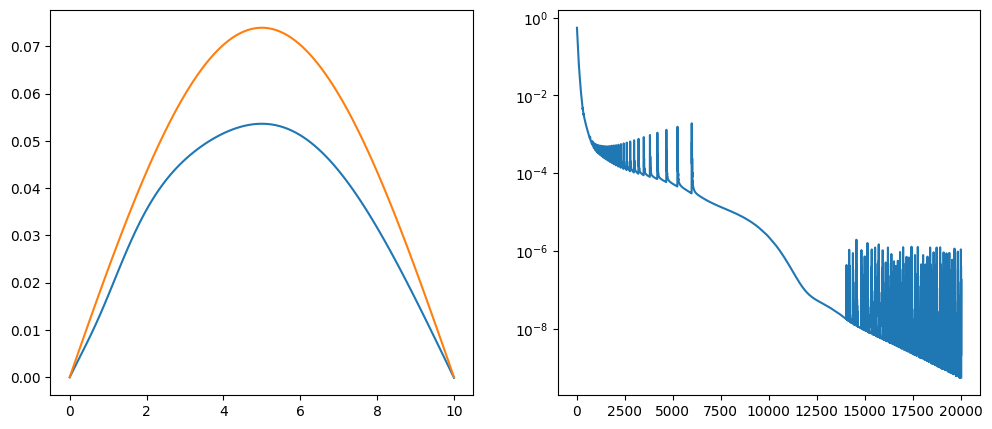

In [4]:
x = torch.linspace(0,10,100).reshape(100,1)
u_exact = q_0*l**4/(np.pi**4*EI)*np.sin(np.pi*x/l)
model.cpu()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))


ax[0].plot(x,model(x).detach().numpy())
ax[0].plot(x,u_exact)

ax[1].plot(loss_vec)
ax[1].set_yscale('log')